***
# <font color=green size=10>**DS-04 - ANÁLISES BÁSICAS DE DADOS PARA ÁREA DA SAÚDE II - AULA 02**</font>
***

## <font color=green size=6>**ÁRVORE DE DECISÃO - REGRESSÃO**</font>

### Inicialmente, vamos importar as bibliotecas necessárias para a construção de nossa árvore de decisão

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn import tree

### Agora vamos importar a base de dados nativa do scikit-learn

In [2]:
# Carregar dados
diabetes = load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

### É preciso separar os dados de nossa base em variáveis independentes e dependente (nosso alvo)

In [3]:
# Separar as features e o target
X = diabetes.data
y = diabetes.target



In [4]:
# Converter para DataFrame para facilitar a visualização
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y
print(df.head())



        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


### Não podemos esquecer de dividir a base em treino e teste

In [5]:
# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Nesse momento, já podemos criar nossa árvore de regressão

In [6]:
# Criar a árvore de regressão
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)



DecisionTreeRegressor(random_state=42)

### Vamos visualizá-la?

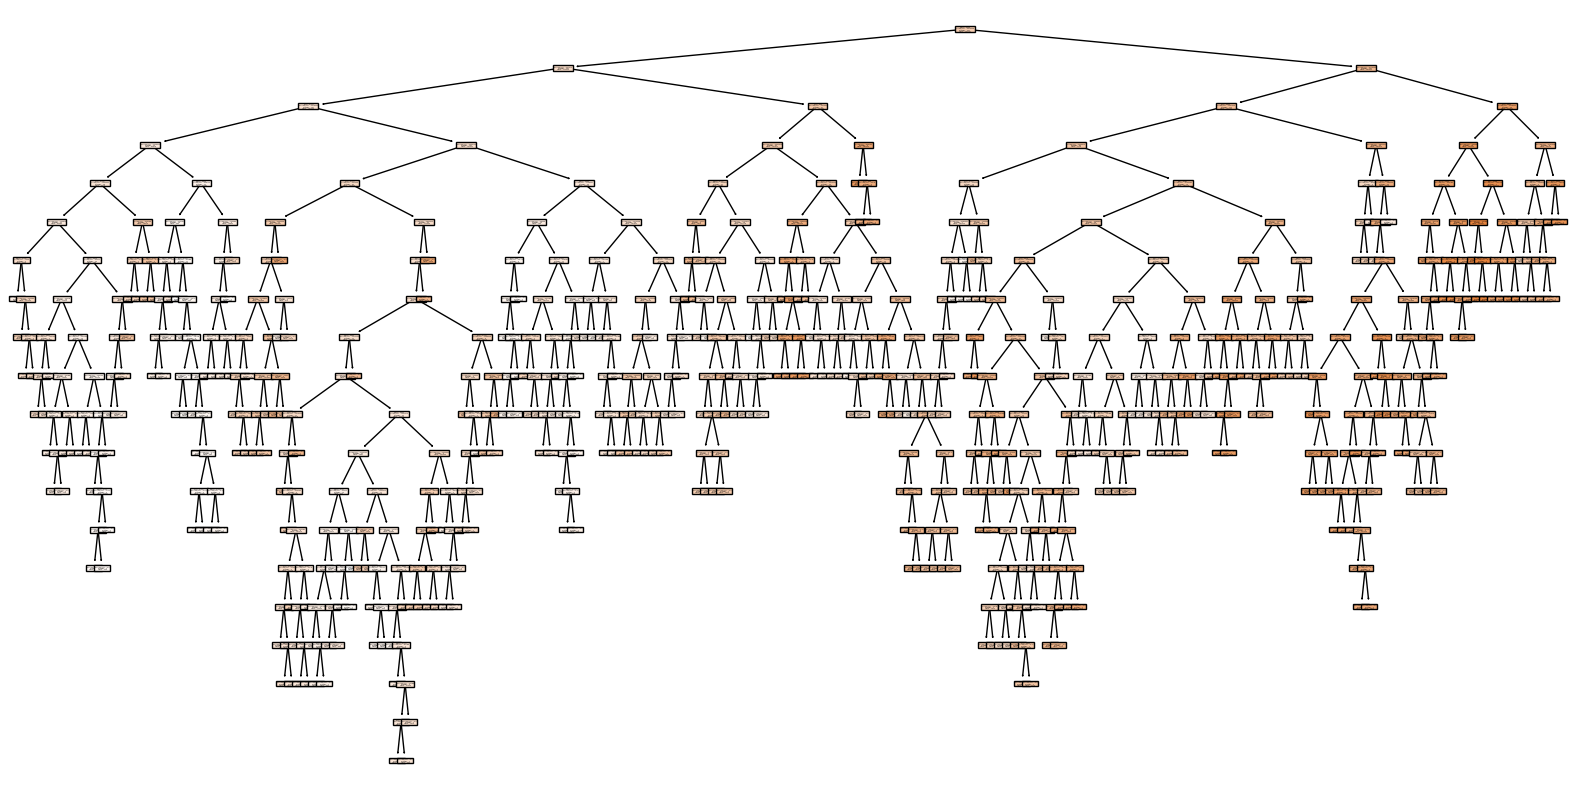

In [7]:
#Visualizar a arvore
plt.figure(figsize=(20,10))
tree.plot_tree(regressor, feature_names=diabetes.feature_names, filled=True)
plt.show()

### Por fim, faremos as predições e avaliaremos nosso modelo construído

In [8]:
# Fazer previsões
y_pred = regressor.predict(X_test)

In [9]:
# Avaliar o modelo
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

#Inserir o erro médio absoluto (Mean Absolut Error - MAE)
mae = np.mean(np.abs(y_pred - y_test))
print("Mean Absolute Error:", mae)

Mean Squared Error: 4976.797752808989
Mean Absolute Error: 54.52808988764045


### 💡 ** Bônus **
### Uma das maneiras de melhorar nossos resultados é ajustando a profundidade máxima de nossa árvore

Mean Squared Error (Optimized): 3568.9652613232283


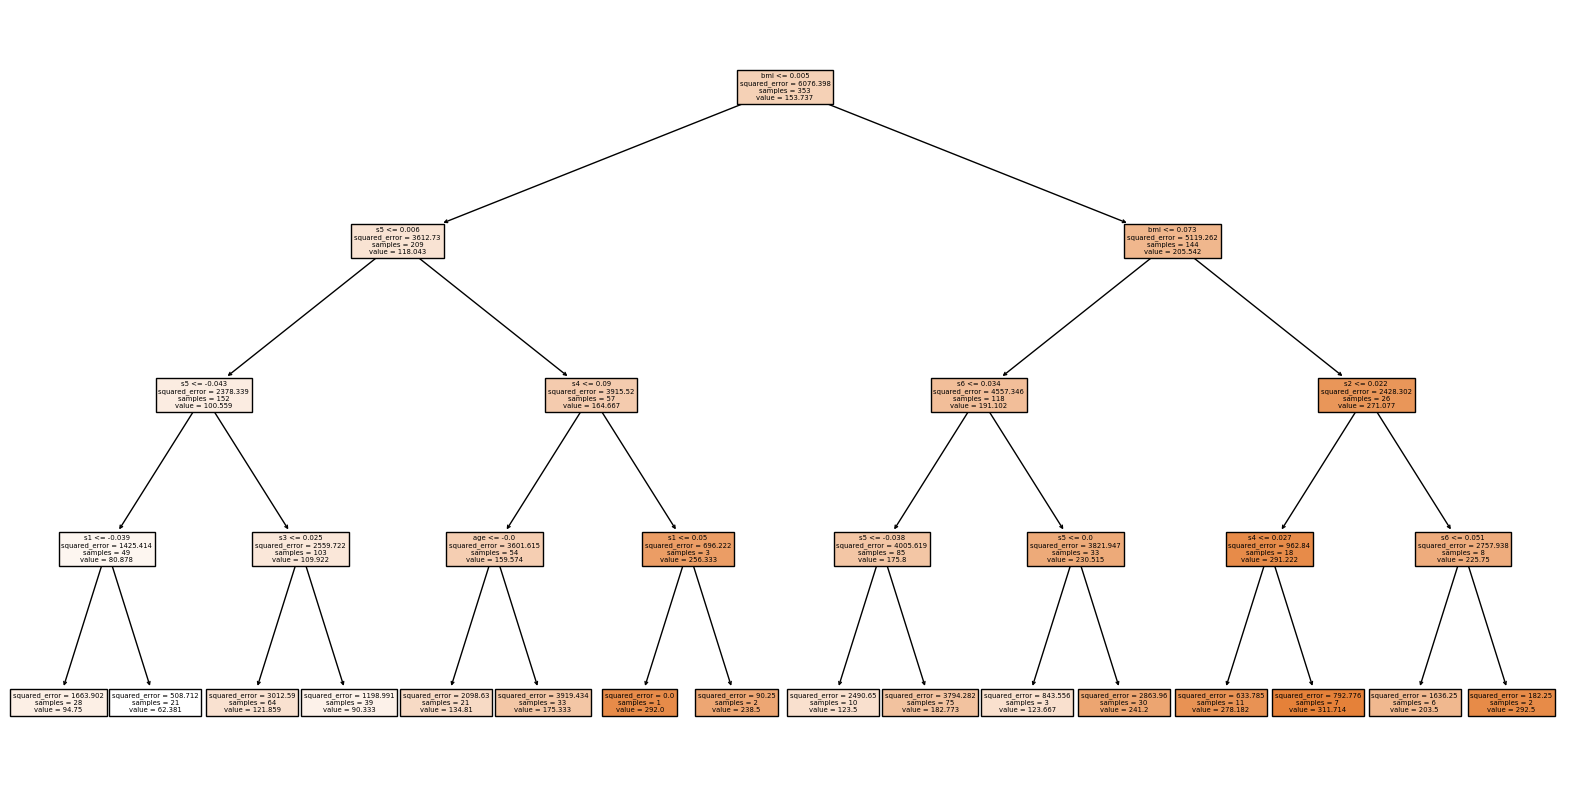

In [10]:
# Treinar o modelo de árvore de regressão com profundidade máxima ajustada
regressor_optimized = DecisionTreeRegressor(max_depth=4, random_state=42)
regressor_optimized.fit(X_train, y_train)

# Fazer previsões e avaliar o modelo
y_pred_optimized = regressor_optimized.predict(X_test)
mse_optimized = mean_squared_error(y_test, y_pred_optimized)
print(f'Mean Squared Error (Optimized): {mse_optimized}')

# Visualizar a árvore de decisão otimizada
plt.figure(figsize=(20,10))
tree.plot_tree(regressor_optimized, feature_names=diabetes.feature_names, filled=True)
plt.show()

# **Exercício**

## Crie uma árvore de Regressão utilizando a base de dados disponível em nosso ambiente virtual de aprendizagem "insurance.csv" para pradizer o valor da variável dependente "charges".

### Siga os passos descritos nas células de códigos abaixo para realizar o exercício.

In [26]:
#importar as bibliotecas necessárias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import plot_tree
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [18]:
# Carregar os dados
data = pd.read_csv('/content/insurance.csv')

In [19]:
# Separar as features e o target
X = data.drop('charges', axis=1)
y = data['charges']

In [20]:
# Visualizar valores de X e y
print(X.head())
print(y.head())

   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [21]:
# Codificar variáveis categóricas (se houver)
categorical_cols = ['sex', 'smoker', 'region']
encoder = OneHotEncoder(handle_unknown='ignore')
X_encoded = pd.DataFrame(encoder.fit_transform(X[categorical_cols]).toarray())
X_encoded = X_encoded.add_prefix('encoded_')
X = X.drop(categorical_cols, axis=1).join(X_encoded)



In [22]:
# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
# Criar a árvore de regressão
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

# Fazer previsões
y_pred = regressor.predict(X_test)

# Avaliar o modelo
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 37981594.4683632


In [24]:
# Fazer previsões
y_pred = regressor.predict(X_test)


In [25]:
# Avaliar o modelo
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

#Inserir o erro médio absoluto (Mean Absolut Error - MAE)
mae = np.mean(np.abs(y_pred - y_test))
print("Mean Absolute Error:", mae)


Mean Squared Error: 37981594.4683632
Mean Absolute Error: 2944.361198119403


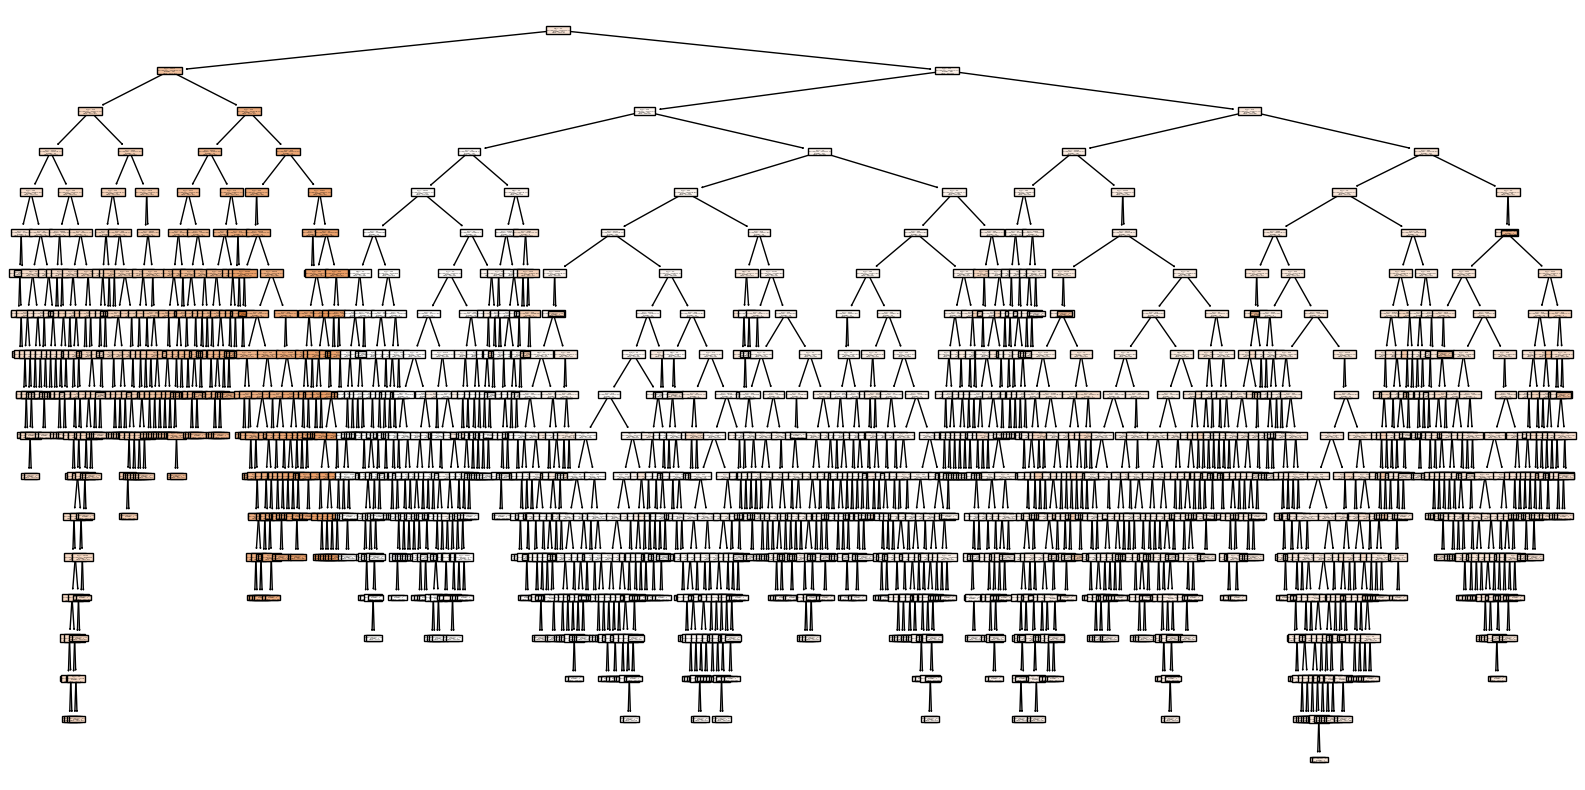

In [27]:
# Visualizar a árvore
plt.figure(figsize=(20,10))
tree.plot_tree(regressor, filled=True)
plt.show()


Mean Squared Error (Optimized): 21093484.004597444


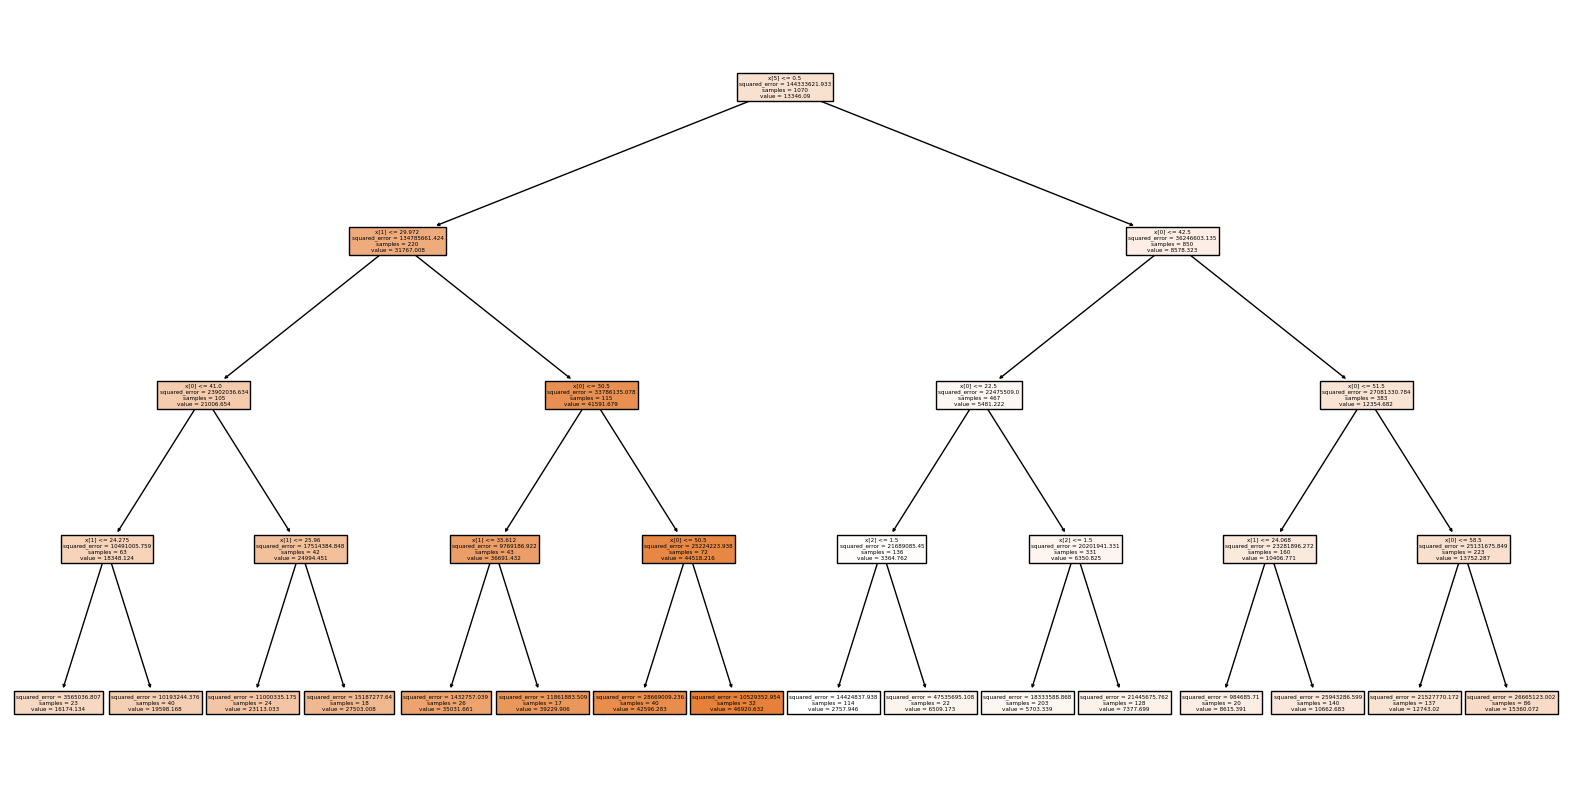

In [28]:
# Treinar o modelo de árvore de regressão com profundidade máxima ajustada
regressor_optimized = DecisionTreeRegressor(max_depth=4, random_state=42)
regressor_optimized.fit(X_train, y_train)

# Fazer previsões e avaliar o modelo
y_pred_optimized = regressor_optimized.predict(X_test)
mse_optimized = mean_squared_error(y_test, y_pred_optimized)
print(f'Mean Squared Error (Optimized): {mse_optimized}')

# Visualizar a árvore de decisão otimizada
plt.figure(figsize=(20,10))
tree.plot_tree(regressor_optimized, filled=True)
plt.show()


In [29]:
# Fazer previsões
y_pred = regressor.predict(X_test)

# Avaliar o modelo
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 37981594.4683632


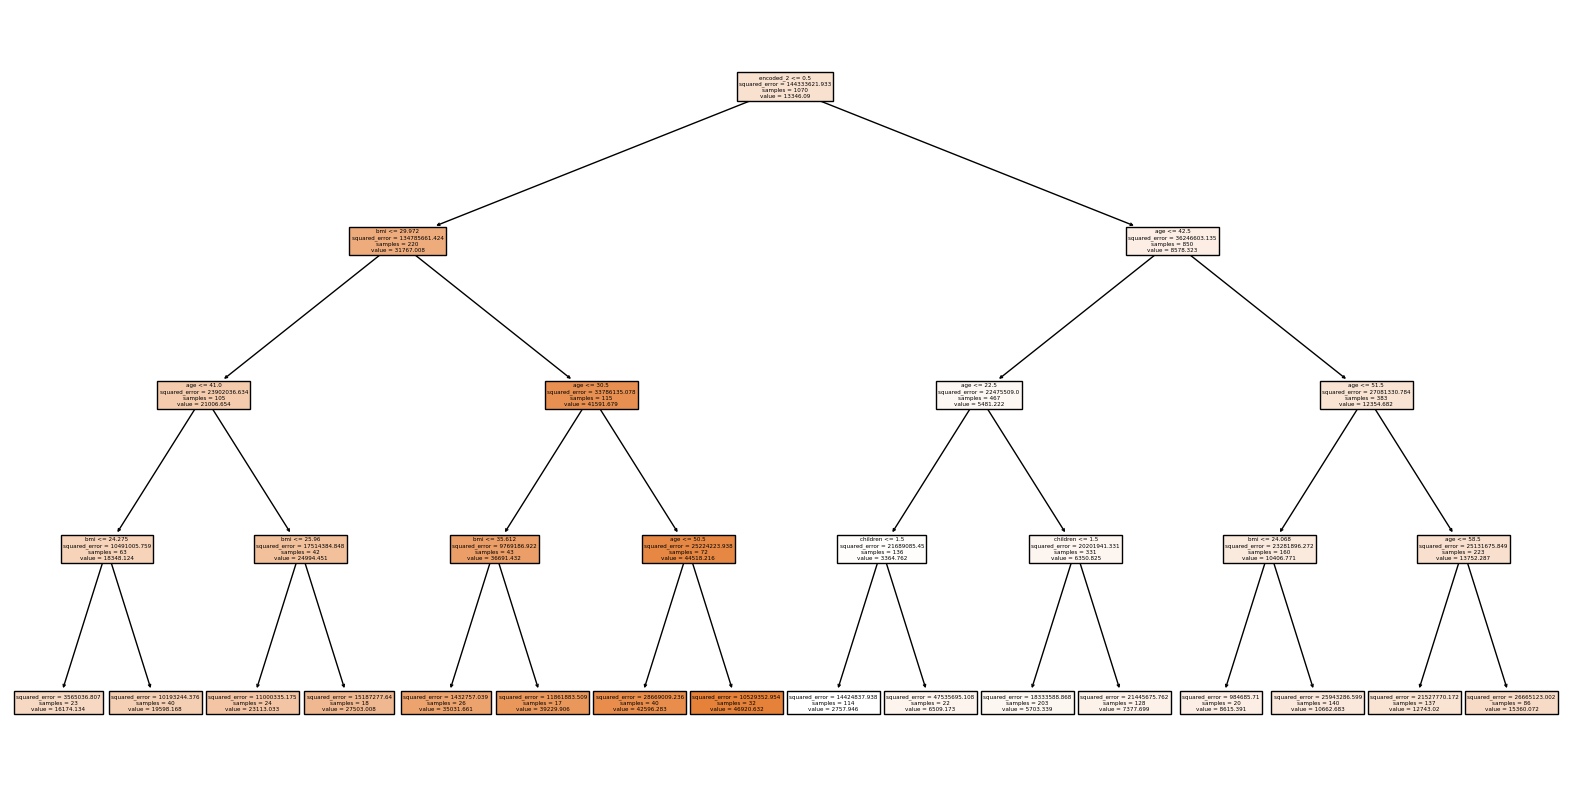

In [31]:
# Visualizar a árvore de decisão otimizada

import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
tree.plot_tree(regressor_optimized, filled=True, feature_names=X.columns)
plt.show()
